In [2]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 63.6 MB/s eta 0:00:00


# Continuous Wave (CV) G2 Correlation Function Simulation

In [10]:
import numpy as np
import pylab as plt
import qutip as qt
from qutip import *

In [11]:
# ==========================================
# 1. PHYSICAL PARAMETERS (The "Space" Specs)
# ==========================================

# Environment
temperature_kelvin = 20.0  # We would modify this

# A. Radioactive Decay | Space Noise Parameter
lifetime_ns = 1.0 # Radiative lifetime (~1 ns)
gamma_decay = 1.0 / lifetime_ns

# B. Radiation-Induced Dephasing | Space Noise Parameter
gamma_dephase_thermal = 0.05 * (temperature_kelvin / 4.0)**2
gamma_dephase_radiation = 0.2
gamma_total_dephase = gamma_dephase_thermal + gamma_dephase_radiation

# C. Stray Light "Pumping" Rate | Space Noise Parameter
# This represents background photons (Sun/Earth) absorbed by the QD.
# 0.0 means perfect darkness. 0.2 means significant light leakage.
gamma_stray_light = 0.15 * gamma_decay

# Drive Power (Rabi Frequency)
# For CW excitation, we keep it comparable to the decay rate to see oscillations
rabi_freq = 2.0 * gamma_decay

print(f"--- Simulation Parameters ---")
print(f"Temperature: {temperature_kelvin} K")
print(f"Excitation Power: {rabi_freq:.3f} GHz")

print("\n")

print(f"--- Space Noise Simulation Parameters ---")
print(f"Decaying Rate: {gamma_decay:.3f} GHz")
print(f"Dephasing (thermal + radiation) Rate: {gamma_total_dephase:.3f} GHz")
print(f"Stray Light Pumping: {gamma_stray_light:.3f} GHz")

print("\n")

--- Simulation Parameters ---
Temperature: 20.0 K
Excitation Power: 2.000 GHz


--- Space Noise Simulation Parameters ---
Decaying Rate: 1.000 GHz
Dephasing (thermal + radiation) Rate: 1.450 GHz
Stray Light Pumping: 0.150 GHz




In [13]:
 # ==========================================
# 2. HAMILTONIAN & DYNAMICS (QuTiP)
# ==========================================

# Operators for a 2-level system
g = qt.basis(2, 0) # Ground
e = qt.basis(2, 1) # Excited
sigma_minus = g * e.dag() # Lowering operator (photon emission)
sigma_plus  = e * g.dag() # Excitation (g -> e)
sigma_z = e * e.dag() - g * g.dag()

# Hamiltonian (H = H0 + H_drive)
# H = hbar * (Omega/2) * (sigma_x)
# (Rotating Frame, Detuning = 0 for simplicity)
H = 0.5 * rabi_freq * (sigma_minus + sigma_minus.dag())

# Collapse Operators (Noise)
c_ops = []
c_ops.append(np.sqrt(gamma_decay) * sigma_minus) # 1. Standard Radiative Decay (Good: Emits our photon)
c_ops.append(np.sqrt(gamma_total_dephase) * sigma_z) # 2. Total Dephasing (Bad: Destroys indistinguishability)
c_ops.append(np.sqrt(gamma_stray_light) * sigma_plus) # 3 Incoherent Excitation (The "Stray Light" Operator)

In [14]:
# ==========================================
# 3. CALCULATE g2(tau)
# ==========================================

rho_ss = qt.steadystate(H, c_ops)
taus = np.linspace(0, 25.0, 200)

# first calculate the occupation number as a function of time
n = mesolve(H, rho_ss, taus, c_ops, [sigma_minus.dag() * sigma_minus]).expect[0]

# calculate the correlation function G2 and normalize with n(0)n(t) to
# obtain g2
G2 = correlation_3op_1t(H, rho_ss, taus, c_ops, sigma_minus.dag(), sigma_minus.dag()*sigma_minus, sigma_minus)
g2 = G2 / (n[0] * n)

/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


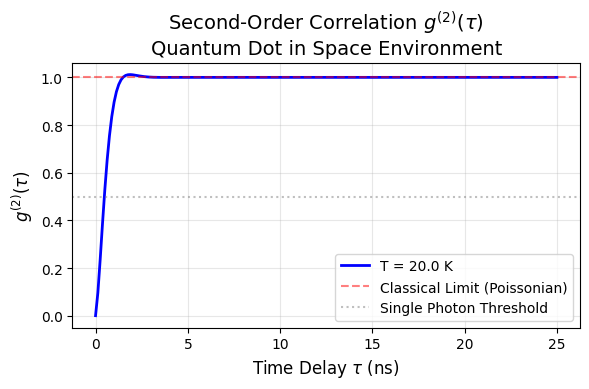

In [15]:
# ==========================================
# 4. PLOTTING THE "DIP"
# ==========================================

plt.figure(figsize=(6, 4))

# Plot the simulated data
plt.plot(taus, np.real(g2), 'b-', linewidth=2, label=f'T = {temperature_kelvin} K')

# Add a visual reference for "Classical Light" limit
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Classical Limit (Poissonian)')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Single Photon Threshold')

plt.title(f'Second-Order Correlation $g^{{(2)}}(\\tau)$\nQuantum Dot in Space Environment', fontsize=14)
plt.xlabel('Time Delay $\\tau$ (ns)', fontsize=12)
plt.ylabel('$g^{(2)}(\\tau)$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()


plt.tight_layout()
plt.show()

# Pulsed Excitation G2 Correlation Function Simulation